# Subthreshold Analysis Notebook

This notebook extracts subthreshold activity from Spike Detector analyzed sessions and analyzes its relation to SS/CS firing and event timing.

Pipeline:
1. Load analyzed sessions from the same master folder/glob pattern used by the analysis workflow.
2. Bleaching correction with sliding-window median baseline (default 1000 ms).
3. Mask and interpolate SS/CS spike windows on raw traces.
4. Zero-phase low-pass filter (default 80 Hz, configurable 50-100 Hz).
5. Analyze subthreshold vs SS/CS spikes and vs event timing (manual or auto-detected puff events).

In [12]:
# ==============================
# SETTINGS (all user settings)
# ==============================
DATA_FOLDER = r'/Users/liangqiyuan/Desktop/20260408_A49_3PCs'
SESSION_GLOB = 'spike_detection/*_analyzed.npz'
STRICT_CELL_NAME_MATCH = True

# Preprocessing
BLEACH_MEDIAN_WINDOW_MS = 1000.0
SPIKE_MASK_SS_MS = (-2.0, 3.0)
SPIKE_MASK_CS_MS = (-8.0, 24.0)
INTERPOLATION_KIND = 'linear'  # currently linear interpolation

# Low-pass filter (recommended 50-100 Hz)
LOWPASS_CUTOFF_HZ = 100.0
LOWPASS_ORDER = 4

# Example visualization selection
EXAMPLE_SESSION_IDX = 0
EXAMPLE_CELL_IDX = 0
EXAMPLE_T_RANGE_MS = (1800.0, 3200.0)

# Whole-recording subthreshold synchrony (pooled across sessions)
SUBTH_SYNC_CONFIG = {
    'enabled': True,
    'metric': 'pearson',
    'jitter_ms': 20.0,
    'n_null_shuffles': 1000,
    'rng_seed': 123,
    'alpha': 0.05,
    'min_valid_samples': 50,
    'show_per_session_matrices': False,
}

# Spike-locked analysis settings
STA_WINDOW_MS = (-100.0, 100.0)
MIN_SPIKES_FOR_STA = 10

# Event settings
EVENT_ONSET_MS = 2510.0
EVENT_DETECTION_CONFIG = {
    'auto_detect_event': True,
    'behavior_csv_glob': '**/*.csv',
    'behavior_state_col': 'Arduino_State',
    'behavior_time_col_candidates': ['Time_s', 'Time_ms', 'time_s', 'time_ms'],
    'behavior_state_on_value': 1,
    'behavior_time_units': 's',
    'max_events_per_session': None,
    'verbose': True,
}
EVENT_LOCK_WINDOW_MS = (-600.0, 1200.0)
EVENT_BASELINE_MS = (-300.0, -0.0)
EVENT_RESPONSE_MS = (0.0, 300.0)

# Optional export
EXPORT_RESULTS = False
EXPORT_DIR = f'{DATA_FOLDER}/subthreshold_exports'

In [2]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.ndimage import median_filter
from scipy.signal import butter, sosfiltfilt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_IPYWIDGETS = True
except Exception:
    HAS_IPYWIDGETS = False

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)

sns.set_theme(style='white', context='talk')
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid': False,
    'figure.dpi': 120,
})

SUBTH_COLORS = {
    'raw': '#4C72B0',
    'baseline': '#DD8452',
    'corrected': '#4C72B0',
    'despiked': '#55A868',
    'subthreshold': '#8172B2',
    'ss': '#4C72B0',
    'cs': '#C44E52',
    'event': '#55A868',
    'pooled': '#4C72B0',
}

if EXPORT_RESULTS:
    os.makedirs(EXPORT_DIR, exist_ok=True)

In [3]:
# ==============================
# Session loading / validation
# ==============================
REQUIRED_KEYS = [
    'time_ms', 'raw_data', 'spike_times_cs', 'spike_times_ss',
    'cell_names', 'fs'
]

def _to_1d_float_array(x):
    arr = np.asarray(x, dtype=float).reshape(-1)
    return arr[np.isfinite(arr)]

def _validate_and_normalize_session(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    missing = [k for k in REQUIRED_KEYS if k not in d.files]
    if missing:
        raise ValueError(f'Missing keys: {missing}')

    time_ms = _to_1d_float_array(d['time_ms'])
    raw_data = np.asarray(d['raw_data'], dtype=float)
    if raw_data.ndim != 2:
        raise ValueError('raw_data must be 2D [samples, cells]')

    n_samples, n_cells = raw_data.shape
    if len(time_ms) != n_samples:
        raise ValueError('time_ms length mismatch')

    cell_names = [str(c) for c in np.asarray(d['cell_names']).tolist()]
    if len(cell_names) != n_cells:
        raise ValueError('cell_names length mismatch')

    spike_times_ss_raw = np.asarray(d['spike_times_ss'], dtype=object)
    spike_times_cs_raw = np.asarray(d['spike_times_cs'], dtype=object)
    if len(spike_times_ss_raw) != n_cells or len(spike_times_cs_raw) != n_cells:
        raise ValueError('spike_times arrays must be length n_cells')

    spike_times_ss = [_to_1d_float_array(spike_times_ss_raw[i]) for i in range(n_cells)]
    spike_times_cs = [_to_1d_float_array(spike_times_cs_raw[i]) for i in range(n_cells)]

    t0, t1 = float(time_ms[0]), float(time_ms[-1])
    for i in range(n_cells):
        spike_times_ss[i] = spike_times_ss[i][(spike_times_ss[i] >= t0) & (spike_times_ss[i] <= t1)]
        spike_times_cs[i] = spike_times_cs[i][(spike_times_cs[i] >= t0) & (spike_times_cs[i] <= t1)]

    fname = os.path.splitext(os.path.basename(npz_path))[0]
    session_name = fname.replace('_analyzed', '')

    return {
        'session_name': session_name,
        'npz_path': npz_path,
        'time_ms': time_ms,
        'raw_data': raw_data,
        'spike_times_ss': spike_times_ss,
        'spike_times_cs': spike_times_cs,
        'n_cells': n_cells,
        'cell_names': cell_names,
        'fs': float(d['fs']),
    }

def _find_session_paths(data_folder, preferred_glob):
    globs_to_try = [
        preferred_glob,
        'spike_detection/*_analyzed.npz',
        '*/*_analyzed.npz',
        '**/*_analyzed.npz',
    ]
    seen = set()
    out = []
    for g in globs_to_try:
        for p in sorted(glob.glob(os.path.join(data_folder, g), recursive=True)):
            if p not in seen:
                seen.add(p)
                out.append(p)
        if out:
            return out, g
    return [], preferred_glob

def load_sessions(data_folder, session_glob='spike_detection/*_analyzed.npz', strict_cell_name_match=True):
    paths, matched_glob = _find_session_paths(data_folder, session_glob)
    if not paths:
        raise FileNotFoundError(f'No session files found under {data_folder}; tried glob={session_glob}')

    loaded, excluded = [], []
    ref_n_cells, ref_cell_names = None, None

    for p in paths:
        try:
            s = _validate_and_normalize_session(p)
            if ref_n_cells is None:
                ref_n_cells = s['n_cells']
                ref_cell_names = s['cell_names']
            else:
                if s['n_cells'] != ref_n_cells:
                    raise ValueError('n_cells mismatch across sessions')
                if strict_cell_name_match and s['cell_names'] != ref_cell_names:
                    raise ValueError('cell_names mismatch (strict mode)')
            loaded.append(s)
        except Exception as e:
            excluded.append({'path': p, 'reason': str(e)})

    if not loaded:
        raise RuntimeError('All session files failed validation.')

    return loaded, excluded, matched_glob

In [4]:
sessions, excluded_sessions, matched_glob = load_sessions(
    DATA_FOLDER,
    session_glob=SESSION_GLOB,
    strict_cell_name_match=STRICT_CELL_NAME_MATCH,
)

print(f'Loaded sessions: {len(sessions)}')
print(f'Excluded sessions: {len(excluded_sessions)}')
print(f'Matched glob: {matched_glob}')
if excluded_sessions:
    for ex in excluded_sessions:
        print(f'- {ex["path"]}: {ex["reason"]}')

n_cells = sessions[0]['n_cells']
cell_names = sessions[0]['cell_names']
summary_df = pd.DataFrame([{
    'session': s['session_name'],
    'duration_ms': float(s['time_ms'][-1] - s['time_ms'][0]),
    'n_cells': s['n_cells'],
    'fs': s['fs'],
    'ss_spikes_total': int(sum(len(x) for x in s['spike_times_ss'])),
    'cs_spikes_total': int(sum(len(x) for x in s['spike_times_cs'])),
} for s in sessions])
display(summary_df)

Loaded sessions: 7
Excluded sessions: 0
Matched glob: spike_detection/*_analyzed.npz


,session,duration_ms,n_cells,fs,ss_spikes_total,cs_spikes_total
0,puff_10,39999.96,3,1010.10101,1471,99
1,puff_1,39999.96,3,1010.10101,1758,95
2,puff_2,39999.96,3,1010.10101,1628,112
3,puff_3,39999.96,3,1010.10101,1698,117
4,puff_5,39999.96,3,1010.10101,1811,111
5,puff_7,39999.96,3,1010.10101,1887,87
6,puff_8,39999.96,3,1010.10101,1477,110


In [5]:
# ==============================
# Event auto-detection helpers
# ==============================
def _find_behavior_csv_for_session(session, event_cfg):
    if not bool(event_cfg.get('auto_detect_event', False)):
        return None

    root = Path(DATA_FOLDER)
    csv_glob = str(event_cfg.get('behavior_csv_glob', '**/*.csv'))
    candidates = sorted(root.glob(csv_glob))
    if not candidates:
        return None

    sname = str(session.get('session_name', '')).lower()
    for p in candidates:
        stem = p.stem.lower()
        if sname and (sname in stem or stem in sname):
            return str(p)

    # fallback: same parent folder if available
    npz_path = Path(str(session.get('npz_path', '')))
    for p in candidates:
        if npz_path.parent in p.parents:
            return str(p)

    return str(candidates[0])

def _detect_event_times_from_behavior_csv(csv_path, event_cfg):
    if csv_path is None or not os.path.exists(csv_path):
        return np.array([], dtype=float)

    df = pd.read_csv(csv_path)
    if df.empty:
        return np.array([], dtype=float)

    state_col = event_cfg.get('behavior_state_col', 'Arduino_State')
    cols_lower = {c.lower(): c for c in df.columns}
    state_col_real = cols_lower.get(str(state_col).lower(), None)
    if state_col_real is None:
        return np.array([], dtype=float)

    time_candidates = event_cfg.get('behavior_time_col_candidates', ['Time_s', 'Time_ms'])
    time_col_real = None
    for tc in time_candidates:
        if str(tc).lower() in cols_lower:
            time_col_real = cols_lower[str(tc).lower()]
            break
    if time_col_real is None:
        return np.array([], dtype=float)

    state_on = float(event_cfg.get('behavior_state_on_value', 1))
    state = pd.to_numeric(df[state_col_real], errors='coerce').fillna(0.0).values
    t_raw = pd.to_numeric(df[time_col_real], errors='coerce').values

    valid = np.isfinite(t_raw)
    if not np.any(valid):
        return np.array([], dtype=float)
    state = state[valid]
    t_raw = t_raw[valid]

    on_mask = state == state_on
    prev_on = np.r_[False, on_mask[:-1]]
    rising = on_mask & (~prev_on)
    ev = t_raw[rising]

    units = str(event_cfg.get('behavior_time_units', 's')).lower()
    if units in {'s', 'sec', 'second', 'seconds'}:
        ev_ms = ev * 1000.0
    else:
        ev_ms = ev

    max_n = event_cfg.get('max_events_per_session', None)
    ev_ms = np.asarray(ev_ms, dtype=float)
    ev_ms = np.unique(np.round(ev_ms, 3))
    if isinstance(max_n, (int, np.integer)) and max_n > 0:
        ev_ms = ev_ms[:int(max_n)]

    return ev_ms

def _get_session_event_times_ms(session, event_cfg, cache=None):
    cache = {} if cache is None else cache
    key = str(session.get('npz_path', session.get('session_name', 'unknown')))
    if key in cache:
        return cache[key]

    default_ev = np.array([float(event_cfg.get('event_time_ms', EVENT_ONSET_MS))], dtype=float)
    if not bool(event_cfg.get('auto_detect_event', False)):
        cache[key] = default_ev
        return default_ev

    csv_path = _find_behavior_csv_for_session(session, event_cfg)
    ev = _detect_event_times_from_behavior_csv(csv_path, event_cfg)
    if ev.size == 0:
        ev = default_ev

    cache[key] = np.asarray(ev, dtype=float)
    return cache[key]

EVENT_CONFIG = {
    'event_time_ms': EVENT_ONSET_MS,
    **EVENT_DETECTION_CONFIG,
}

In [6]:
# ==============================
# Subthreshold extraction
# ==============================
def _ensure_odd(n):
    n = int(max(3, n))
    return n if n % 2 == 1 else n + 1

def sliding_median_baseline(trace, fs, window_ms=1000.0):
    win = _ensure_odd(int(round((window_ms / 1000.0) * fs)))
    baseline = median_filter(np.asarray(trace, dtype=float), size=win, mode='nearest')
    return baseline

def _mask_windows_from_spikes(n_samples, fs, spike_times_ms, window_ms):
    mask = np.zeros(n_samples, dtype=bool)
    if spike_times_ms is None:
        return mask
    sidx = np.round(np.asarray(spike_times_ms, dtype=float) * fs / 1000.0).astype(int)
    w0, w1 = float(window_ms[0]), float(window_ms[1])
    for p in sidx:
        a = int(round(p + (w0 / 1000.0) * fs))
        b = int(round(p + (w1 / 1000.0) * fs))
        lo, hi = sorted((a, b))
        lo = max(0, lo)
        hi = min(n_samples - 1, hi)
        if hi >= lo:
            mask[lo:hi+1] = True
    return mask

def mask_and_interpolate_spikes(trace, fs, ss_times_ms, cs_times_ms, ss_window_ms, cs_window_ms):
    x = np.asarray(trace, dtype=float).copy()
    n = len(x)
    bad = _mask_windows_from_spikes(n, fs, ss_times_ms, ss_window_ms) | _mask_windows_from_spikes(n, fs, cs_times_ms, cs_window_ms)
    if not np.any(bad):
        return x, bad

    good_idx = np.where(~bad)[0]
    if len(good_idx) < 2:
        return x, bad

    x[bad] = np.interp(np.where(bad)[0], good_idx, x[good_idx])
    return x, bad

def lowpass_zero_phase(trace, fs, cutoff_hz=80.0, order=3):
    x = np.asarray(trace, dtype=float)
    nyq = 0.5 * float(fs)
    c = float(cutoff_hz)
    if c <= 0 or c >= nyq:
        raise ValueError(f'Invalid cutoff_hz={c}; must be in (0, {nyq})')
    wn = c / nyq
    sos = butter(int(order), wn, btype='low', output='sos')
    return sosfiltfilt(sos, x)

def build_subthreshold_dataset(sessions):
    out = []
    for s in sessions:
        raw = np.asarray(s['raw_data'], dtype=float)
        fs = float(s['fs'])
        n_samples, n_cells_local = raw.shape

        baseline_mat = np.zeros_like(raw, dtype=float)
        corrected_mat = np.zeros_like(raw, dtype=float)
        despiked_mat = np.zeros_like(raw, dtype=float)
        subth_mat = np.zeros_like(raw, dtype=float)
        masked_fraction = np.zeros(n_cells_local, dtype=float)

        for c in range(n_cells_local):
            trace = raw[:, c]
            baseline = sliding_median_baseline(trace, fs, window_ms=BLEACH_MEDIAN_WINDOW_MS)
            corrected = trace - baseline
            despiked, bad = mask_and_interpolate_spikes(
                corrected, fs,
                s['spike_times_ss'][c], s['spike_times_cs'][c],
                SPIKE_MASK_SS_MS, SPIKE_MASK_CS_MS
            )
            subth = lowpass_zero_phase(despiked, fs, cutoff_hz=LOWPASS_CUTOFF_HZ, order=LOWPASS_ORDER)

            baseline_mat[:, c] = baseline
            corrected_mat[:, c] = corrected
            despiked_mat[:, c] = despiked
            subth_mat[:, c] = subth
            masked_fraction[c] = float(np.mean(bad))

        s_out = dict(s)
        s_out.update({
            'baseline': baseline_mat,
            'corrected': corrected_mat,
            'despiked': despiked_mat,
            'subthreshold': subth_mat,
            'masked_fraction': masked_fraction,
        })
        out.append(s_out)

    return out

In [7]:
processed_sessions = build_subthreshold_dataset(sessions)

qc_df = pd.DataFrame([{
    'session': s['session_name'],
    'n_cells': s['n_cells'],
    'mean_masked_fraction': float(np.mean(s['masked_fraction'])),
    'max_masked_fraction': float(np.max(s['masked_fraction'])),
} for s in processed_sessions])
display(qc_df)

,session,n_cells,mean_masked_fraction,max_masked_fraction
0,puff_10,3,0.098288,0.108303
1,puff_1,3,0.110712,0.141765
2,puff_2,3,0.109236,0.127905
3,puff_3,3,0.113616,0.131023
4,puff_5,3,0.117791,0.133820
5,puff_7,3,0.115002,0.124539
6,puff_8,3,0.101291,0.101695


In [8]:
# Example subthreshold visualization with interactive window controls
def plot_example_window(session_idx, cell_idx, center_ms, window_ms):
    s = processed_sessions[int(np.clip(session_idx, 0, len(processed_sessions) - 1))]
    c = int(np.clip(cell_idx, 0, s['n_cells'] - 1))
    t = s['time_ms']
    half = max(50.0, float(window_ms) / 2.0)
    t0 = float(center_ms) - half
    t1 = float(center_ms) + half
    mask = (t >= t0) & (t <= t1)

    if np.sum(mask) < 5:
        print('Selected window has too few samples; increase window size or move center.')
        return

    fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
    axes[0].plot(t[mask], s['raw_data'][mask, c], color=SUBTH_COLORS['raw'], lw=1)
    axes[0].set_title(f"Raw trace | session={s['session_name']} | cell={s['cell_names'][c]}")

    axes[1].plot(t[mask], s['baseline'][mask, c], color=SUBTH_COLORS['baseline'], lw=1.2)
    axes[1].set_title('Sliding median baseline (bleaching estimate)')

    axes[2].plot(t[mask], s['corrected'][mask, c], color=SUBTH_COLORS['corrected'], lw=1)
    axes[2].set_title('Bleaching-corrected trace (raw - baseline)')

    axes[3].plot(t[mask], s['despiked'][mask, c], color=SUBTH_COLORS['despiked'], lw=1)
    axes[3].set_title('After SS/CS masking + interpolation')

    axes[4].plot(t[mask], s['subthreshold'][mask, c], color=SUBTH_COLORS['subthreshold'], lw=1.4)
    axes[4].set_title(f'Subthreshold (zero-phase low-pass {LOWPASS_CUTOFF_HZ:g} Hz)')
    axes[4].set_xlabel('Time (ms)')

    for ax in axes:
        sns.despine(ax=ax, left=True, bottom=True)

    plt.show()

default_center = float(np.mean(EXAMPLE_T_RANGE_MS))
default_window = float(EXAMPLE_T_RANGE_MS[1] - EXAMPLE_T_RANGE_MS[0])

if HAS_IPYWIDGETS:
    t_min = float(min(s['time_ms'][0] for s in processed_sessions))
    t_max = float(max(s['time_ms'][-1] for s in processed_sessions))

    session_slider = widgets.IntSlider(
        value=int(EXAMPLE_SESSION_IDX), min=0, max=len(processed_sessions) - 1, step=1, description='Session'
    )
    cell_slider = widgets.IntSlider(
        value=int(EXAMPLE_CELL_IDX), min=0, max=n_cells - 1, step=1, description='Cell'
    )
    center_slider = widgets.FloatSlider(
        value=default_center, min=t_min, max=t_max, step=10.0, description='Center (ms)', continuous_update=False
    )
    window_slider = widgets.FloatSlider(
        value=max(100.0, default_window), min=100.0, max=min(10000.0, t_max - t_min), step=50.0,
        description='Window (ms)', continuous_update=False
    )

    ui = widgets.VBox([session_slider, cell_slider, center_slider, window_slider])
    out = widgets.interactive_output(
        plot_example_window,
        {'session_idx': session_slider, 'cell_idx': cell_slider, 'center_ms': center_slider, 'window_ms': window_slider}
    )
    display(ui, out)
else:
    print('ipywidgets unavailable; showing static window. Install ipywidgets for sliders.')
    plot_example_window(EXAMPLE_SESSION_IDX, EXAMPLE_CELL_IDX, default_center, max(100.0, default_window))

Output()

,session,cell_i,cell_j,i,j,r,p,z
0,puff_10,avr (UG)(),avr (UG)().1,0,1,0.441870,0.000999,12.618168
1,puff_10,avr (UG)(),avr (UG)().2,0,2,0.158343,0.000999,10.368064
2,puff_10,avr (UG)().1,avr (UG)().2,1,2,0.175003,0.000999,16.252905
3,puff_1,avr (UG)(),avr (UG)().1,0,1,0.360408,0.000999,17.422588
4,puff_1,avr (UG)(),avr (UG)().2,0,2,0.071898,0.164835,0.953629
5,puff_1,avr (UG)().1,avr (UG)().2,1,2,0.077122,0.000999,8.268367
6,puff_2,avr (UG)(),avr (UG)().1,0,1,0.456537,0.000999,10.178129
7,puff_2,avr (UG)(),avr (UG)().2,0,2,0.123680,1.000000,-4.087964
8,puff_2,avr (UG)().1,avr (UG)().2,1,2,0.243891,0.000999,16.987549
9,puff_3,avr (UG)(),avr (UG)().1,0,1,0.512147,0.000999,15.851229


Pooled subthreshold synchrony summary:


,cell_i,cell_j,mean_metric,p,n_sessions,q
0,avr (UG)(),avr (UG)().1,0.443216,2.008014e-14,7,3.012021e-14
1,avr (UG)(),avr (UG)().2,0.183006,2.184663e-05,7,2.184663e-05
2,avr (UG)().1,avr (UG)().2,0.256347,2.008014e-14,7,3.012021e-14


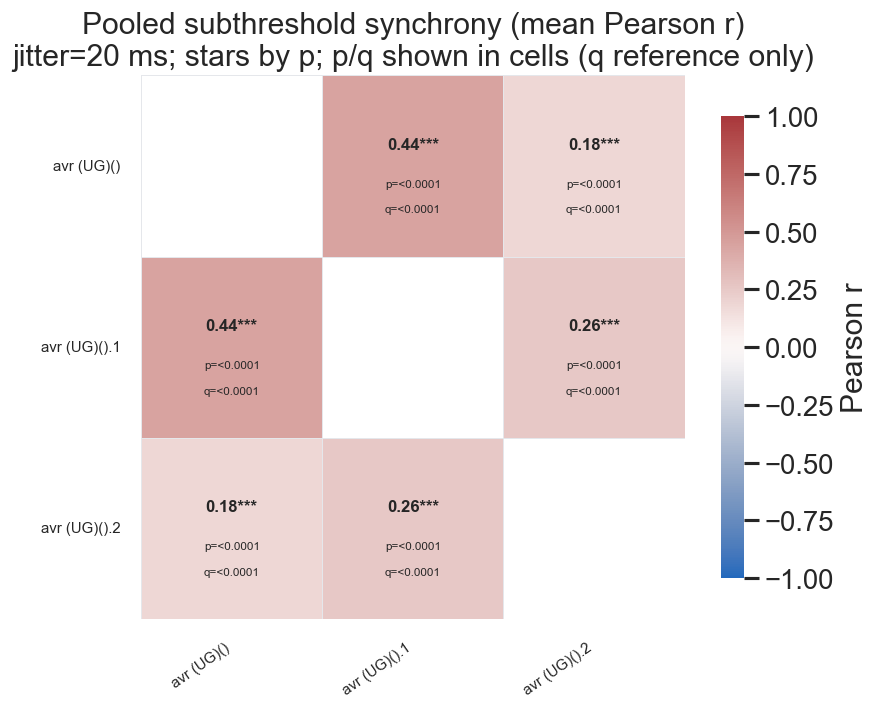

In [13]:
# ==============================
# Pooled subthreshold synchrony (whole recording)
# ==============================
def _subthsync_safe_corr(x, y, min_valid_samples=50):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) < int(min_valid_samples):
        return np.nan
    x = x[good]
    y = y[good]
    if np.std(x) <= 0 or np.std(y) <= 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _subthsync_jitter_trace(trace, fs, jitter_ms, rng):
    trace = np.asarray(trace, dtype=float)
    n = trace.size
    if n == 0:
        return trace.copy()
    jitter_samples = max(1.0, float(jitter_ms) * float(fs) / 1000.0)
    x = np.arange(n, dtype=float)
    sample_points = np.clip(x + rng.uniform(-jitter_samples, jitter_samples, size=n), 0.0, float(max(0, n - 1)))
    return np.interp(sample_points, x, trace)


def _subthsync_shuffle_significance(trace_a, trace_b, fs, cfg, rng):
    min_valid = int(cfg.get('min_valid_samples', 50))
    obs = _subthsync_safe_corr(trace_a, trace_b, min_valid_samples=min_valid)
    if not np.isfinite(obs):
        return np.nan, np.nan, np.nan

    jitter_ms = float(cfg.get('jitter_ms', 20.0))
    n_shuffles = int(cfg.get('n_null_shuffles', 1000))
    null_vals = []
    for _ in range(n_shuffles):
        jittered_b = _subthsync_jitter_trace(trace_b, fs, jitter_ms, rng)
        r_null = _subthsync_safe_corr(trace_a, jittered_b, min_valid_samples=min_valid)
        if np.isfinite(r_null):
            null_vals.append(float(r_null))

    null_vals = np.asarray(null_vals, dtype=float)
    null_vals = null_vals[np.isfinite(null_vals)]
    if null_vals.size == 0:
        return float(obs), np.nan, np.nan

    p_two = (np.sum(np.abs(null_vals) >= abs(obs)) + 1.0) / (null_vals.size + 1.0)
    z = (obs - np.mean(null_vals)) / (np.std(null_vals) + 1e-9)
    return float(obs), float(p_two), float(z)


def _subthsync_bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    finite = np.isfinite(p)
    if not np.any(finite):
        return q
    pf = p[finite]
    order = np.argsort(pf)
    ranked = pf[order]
    m = len(ranked)
    q_ranked = ranked * m / np.arange(1, m + 1)
    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]
    q_ranked = np.clip(q_ranked, 0.0, 1.0)
    back = np.empty_like(q_ranked)
    back[order] = q_ranked
    q[finite] = back
    return q


def _subthsync_combine_pair_pvalues_fisher(pvals):
    from scipy.stats import chi2

    vals = np.asarray(pvals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = vals[(vals > 0.0) & (vals <= 1.0)]
    if vals.size == 0:
        return np.nan
    if vals.size == 1:
        return float(vals[0])
    stat = -2.0 * np.sum(np.log(vals))
    return float(chi2.sf(stat, 2 * vals.size))


def _subthsync_pair_matrix(cell_names_local, pair_df_local, value_col):
    n_local = len(cell_names_local)
    mat = np.full((n_local, n_local), np.nan, dtype=float)
    for row in pair_df_local.itertuples(index=False):
        ci = str(row.cell_i)
        cj = str(row.cell_j)
        if ci not in cell_names_local or cj not in cell_names_local:
            continue
        i = cell_names_local.index(ci)
        j = cell_names_local.index(cj)
        val = pd.to_numeric(getattr(row, value_col), errors='coerce')
        if np.isfinite(val):
            mat[i, j] = float(val)
            mat[j, i] = float(val)
    return mat


def _subthsync_format_sig_value(val):
    val = pd.to_numeric(val, errors='coerce')
    if not np.isfinite(val):
        return 'na'
    if val < 0.0001:
        return '<0.0001'
    return f'{float(val):.4f}'


def _subthsync_p_stars(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return ''


def _subthsync_overlay_text(ax, value_mat, p_mat=None, q_mat=None):
    for i in range(value_mat.shape[0]):
        for j in range(value_mat.shape[1]):
            val = value_mat[i, j]
            if not np.isfinite(val):
                continue
            x = j + 0.5
            y = i + 0.5
            if i == j:
                ax.text(x, y, f'{val:.2f}', ha='center', va='center', fontsize=10, fontweight='bold')
                continue
            p_val = np.nan if p_mat is None else p_mat[i, j]
            q_val = np.nan if q_mat is None else q_mat[i, j]
            stars = _subthsync_p_stars(p_val)
            ax.text(x, y - 0.12, f'{val:.2f}{stars}', ha='center', va='center', fontsize=10, fontweight='bold')
            ax.text(x, y + 0.10, f'p={_subthsync_format_sig_value(p_val)}', ha='center', va='center', fontsize=7)
            if np.isfinite(q_val):
                ax.text(x, y + 0.24, f'q={_subthsync_format_sig_value(q_val)}', ha='center', va='center', fontsize=7)


if not bool(SUBTH_SYNC_CONFIG.get('enabled', True)):
    print('Subthreshold synchrony section is disabled. Set SUBTH_SYNC_CONFIG["enabled"] = True to show it.')
elif n_cells < 2:
    print('Single-cell dataset detected (n_cells=1). Skipping subthreshold synchrony matrices.')
else:
    rng = np.random.default_rng(int(SUBTH_SYNC_CONFIG.get('rng_seed', 123)))
    subth_sync_rows = []

    for s in processed_sessions:
        subth = np.asarray(s['subthreshold'], dtype=float)
        fs = float(s['fs'])
        for i in range(s['n_cells']):
            for j in range(i + 1, s['n_cells']):
                obs_r, p_val, z_val = _subthsync_shuffle_significance(
                    subth[:, i], subth[:, j], fs, SUBTH_SYNC_CONFIG, rng
                )
                subth_sync_rows.append({
                    'session': s['session_name'],
                    'cell_i': s['cell_names'][i],
                    'cell_j': s['cell_names'][j],
                    'i': i,
                    'j': j,
                    'r': obs_r,
                    'p': p_val,
                    'z': z_val,
                })

    subth_sync_df = pd.DataFrame(subth_sync_rows)
    display(subth_sync_df.head(20))

    pooled_rows = []
    for (cell_i, cell_j), grp in subth_sync_df.groupby(['cell_i', 'cell_j'], sort=False):
        vals = pd.to_numeric(grp['r'], errors='coerce').dropna().to_numpy(dtype=float)
        p_vals = pd.to_numeric(grp['p'], errors='coerce').dropna().to_numpy(dtype=float)
        pooled_rows.append({
            'cell_i': cell_i,
            'cell_j': cell_j,
            'mean_metric': float(np.nanmean(vals)) if vals.size else np.nan,
            'p': _subthsync_combine_pair_pvalues_fisher(p_vals),
            'n_sessions': int(grp['session'].nunique()),
        })

    pooled_subth_sync_summary = pd.DataFrame(pooled_rows)
    if not pooled_subth_sync_summary.empty:
        pooled_subth_sync_summary['q'] = _subthsync_bh_fdr(pooled_subth_sync_summary['p'].values)

    print('Pooled subthreshold synchrony summary:')
    display(pooled_subth_sync_summary)

    pooled_subth_sync_mat = _subthsync_pair_matrix(cell_names, pooled_subth_sync_summary, 'mean_metric')
    pooled_subth_p_mat = _subthsync_pair_matrix(cell_names, pooled_subth_sync_summary, 'p')
    pooled_subth_q_mat = _subthsync_pair_matrix(cell_names, pooled_subth_sync_summary, 'q')

    fig_w = max(7.5, 0.95 * n_cells + 4.8)
    fig_h = max(5.8, 0.95 * n_cells + 1.6)
    fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h), constrained_layout=True)
    sns.heatmap(
        pooled_subth_sync_mat,
        ax=ax,
        annot=False,
        fmt='',
        cmap='vlag',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        xticklabels=cell_names,
        yticklabels=cell_names,
        linewidths=0.5,
        linecolor='#E5E7EB',
        cbar_kws={'shrink': 0.85, 'label': 'Pearson r'},
    )
    ax.set_aspect('equal', adjustable='box')
    _subthsync_overlay_text(ax, pooled_subth_sync_mat, pooled_subth_p_mat, pooled_subth_q_mat)
    ax.set_title(
        f'Pooled subthreshold synchrony (mean Pearson r)\n'
        f'jitter={float(SUBTH_SYNC_CONFIG.get("jitter_ms", 20.0)):g} ms; stars by p; p/q shown in cells (q reference only)'
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    sns.despine(ax=ax, left=True, bottom=True)
    plt.show()

    if bool(SUBTH_SYNC_CONFIG.get('show_per_session_matrices', False)):
        for s in processed_sessions:
            sub = subth_sync_df[subth_sync_df['session'] == s['session_name']].copy()
            if sub.empty:
                continue
            sub['q'] = _subthsync_bh_fdr(pd.to_numeric(sub['p'], errors='coerce').values)
            mat = _subthsync_pair_matrix(cell_names, sub, 'r')
            p_mat = _subthsync_pair_matrix(cell_names, sub, 'p')
            q_mat = _subthsync_pair_matrix(cell_names, sub, 'q')
            fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h), constrained_layout=True)
            sns.heatmap(
                mat,
                ax=ax,
                annot=False,
                fmt='',
                cmap='vlag',
                center=0,
                vmin=-1,
                vmax=1,
                square=True,
                xticklabels=cell_names,
                yticklabels=cell_names,
                linewidths=0.5,
                linecolor='#E5E7EB',
                cbar_kws={'shrink': 0.85, 'label': 'Pearson r'},
            )
            ax.set_aspect('equal', adjustable='box')
            _subthsync_overlay_text(ax, mat, p_mat, q_mat)
            ax.set_title(
                f'{s["session_name"]}: subthreshold synchrony (Pearson r)\n'
                f'jitter={float(SUBTH_SYNC_CONFIG.get("jitter_ms", 20.0)):g} ms; stars by p; p/q shown in cells (q reference only)'
            )
            ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
            sns.despine(ax=ax, left=True, bottom=True)
            plt.show()

,session,cell,spike_type,n_spikes,subth_at_spike_mean,subth_at_spike_std,pre_spike_slope_mean
0,puff_10,avr (UG)(),SS,564,0.692205,11.433828,-0.079511
1,puff_10,avr (UG)(),CS,32,-2.804951,9.567863,-0.156970
2,puff_10,avr (UG)().1,SS,473,1.826587,11.696350,-0.138650
3,puff_10,avr (UG)().1,CS,49,-0.269337,7.362006,-0.064768
4,puff_10,avr (UG)().2,SS,434,4.395296,12.571556,-0.070513
5,puff_10,avr (UG)().2,CS,18,0.727191,9.917470,-0.362908
6,puff_1,avr (UG)(),SS,620,2.352971,15.218008,-0.109681
7,puff_1,avr (UG)(),CS,31,2.945415,12.352928,-0.434137
8,puff_1,avr (UG)().1,SS,674,-4.321978,31.772786,-0.128737
9,puff_1,avr (UG)().1,CS,56,-5.076669,22.595681,-0.136782


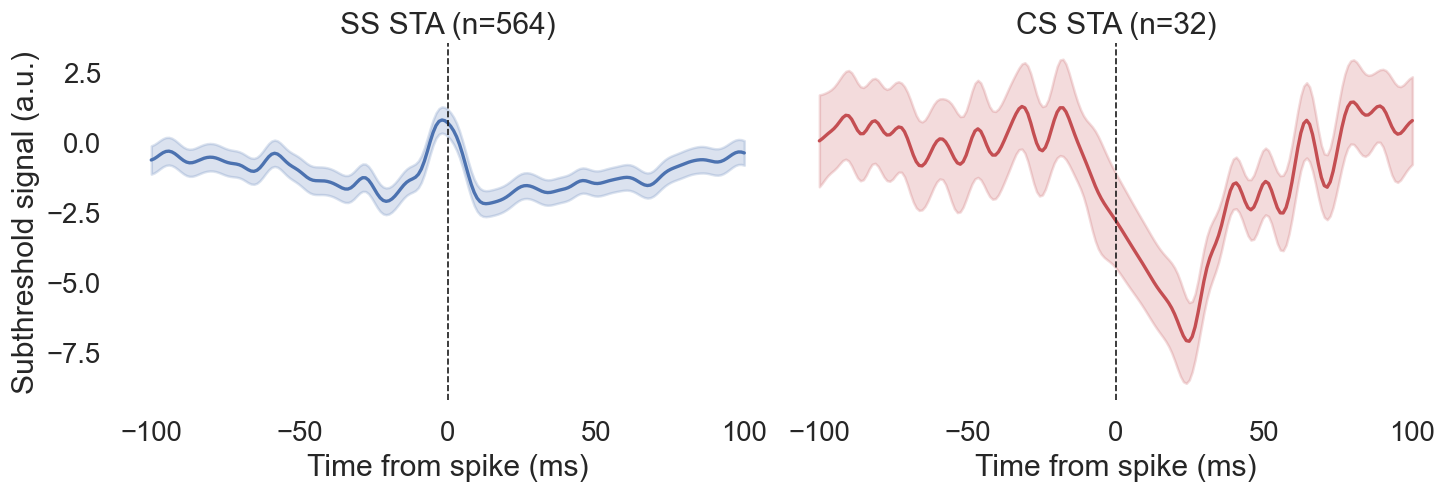

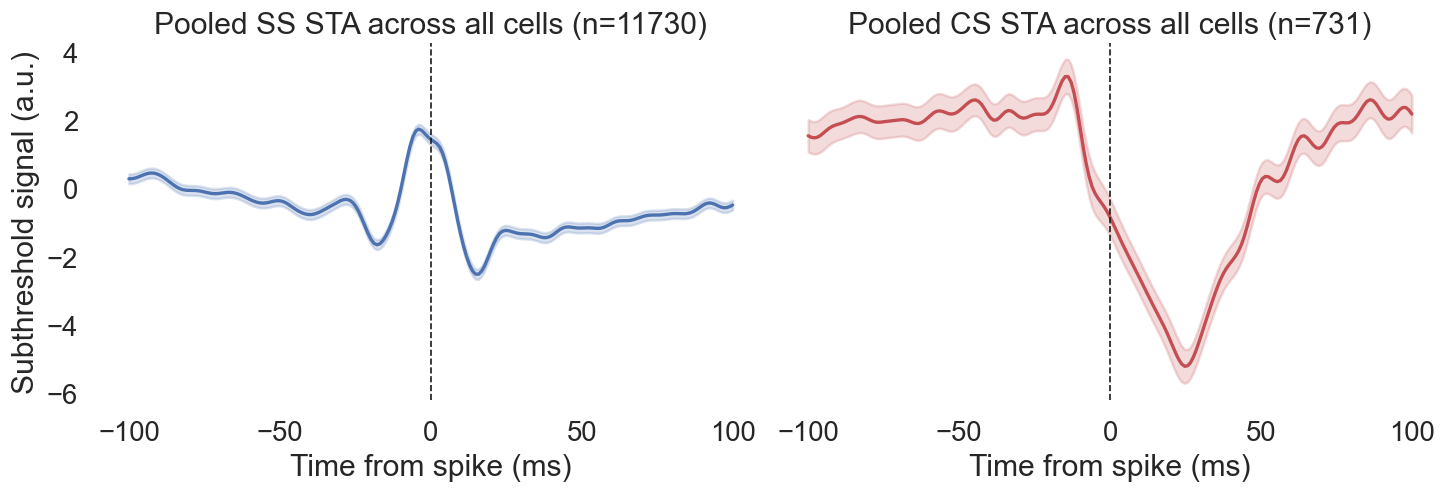

,spike_type,pooled_n,sum_of_per_cell_n
0,SS,11730,11730
1,CS,731,731


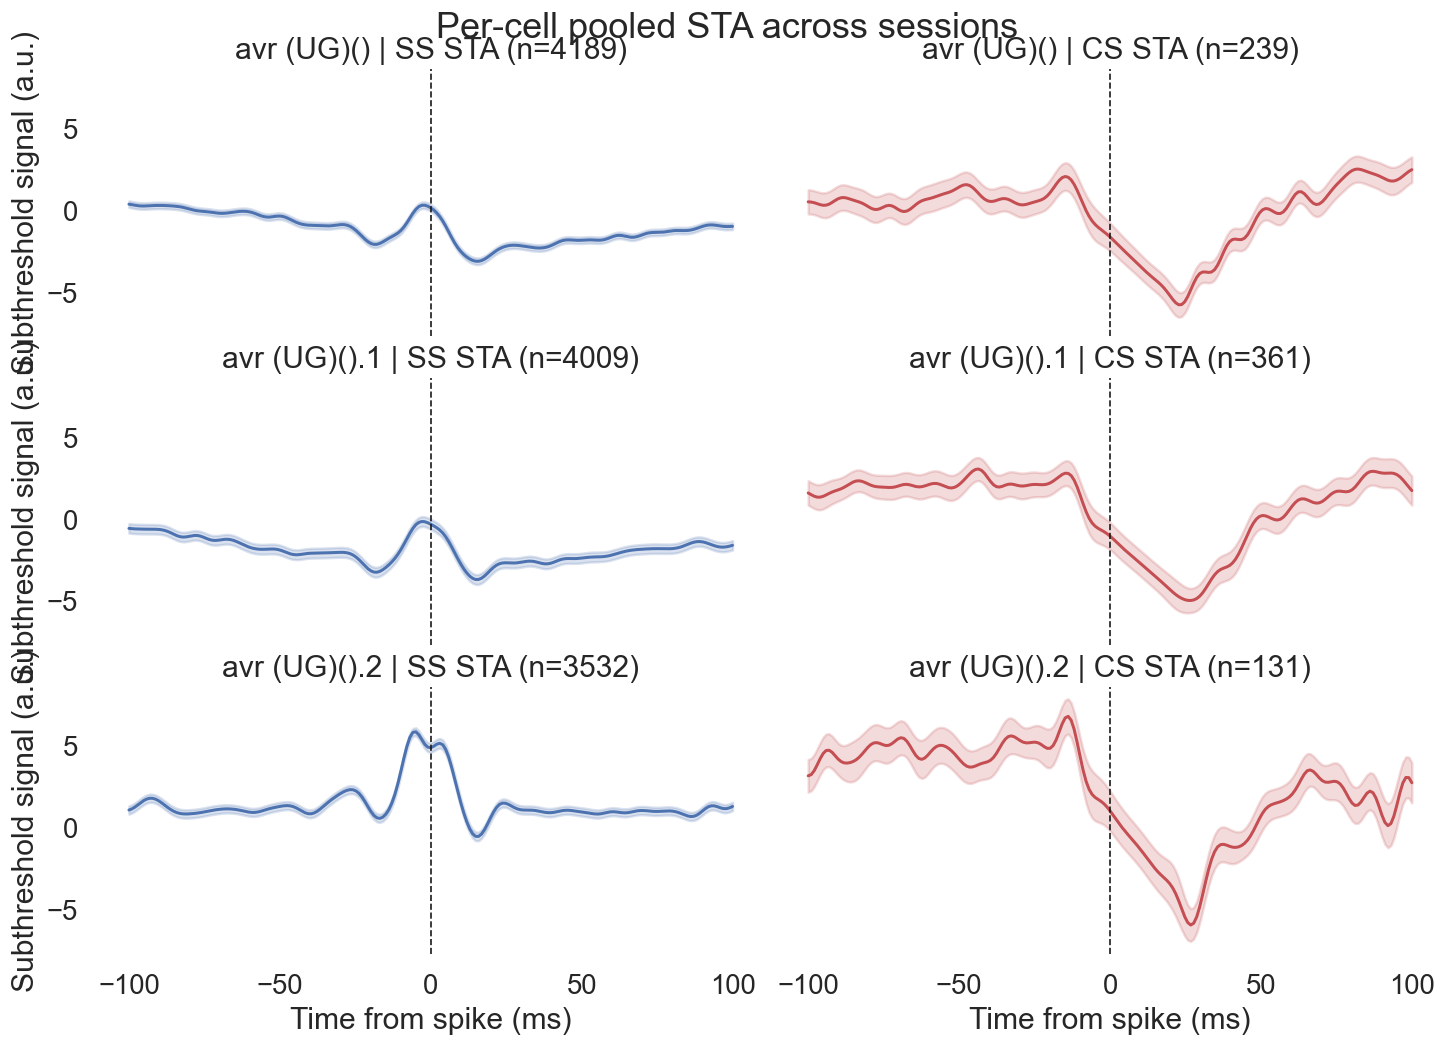

In [9]:
# ==============================

# Subthreshold <-> SS/CS relation

# ==============================

def _valid_spike_indices(spike_times_ms, fs, trace_len):

    idx = np.round(np.asarray(spike_times_ms, dtype=float) * fs / 1000.0).astype(int)

    return idx[(idx >= 0) & (idx < int(trace_len))]



def _extract_spike_snippets(trace, spike_times_ms, fs, window_ms=(-150, 150), allow_partial=True):

    pre_s = int(round((window_ms[0] / 1000.0) * fs))

    post_s = int(round((window_ms[1] / 1000.0) * fs))

    if post_s <= pre_s:

        raise ValueError('Invalid STA window')

    trace = np.asarray(trace, dtype=float)

    idx = _valid_spike_indices(spike_times_ms, fs, len(trace))

    if len(idx) == 0:

        return None, None

    snippet_len = post_s - pre_s + 1

    snippets = []

    for p in idx:

        a = p + pre_s

        b = p + post_s + 1

        if (a < 0 or b > len(trace)) and (not allow_partial):

            continue

        snippet = np.full(snippet_len, np.nan, dtype=float)

        src_a = max(0, a)

        src_b = min(len(trace), b)

        if src_b <= src_a:

            continue

        dst_a = src_a - a

        dst_b = dst_a + (src_b - src_a)

        snippet[dst_a:dst_b] = trace[src_a:src_b]

        snippets.append(snippet)

    if len(snippets) == 0:

        return None, None

    arr = np.vstack(snippets)

    rel_t = np.arange(pre_s, post_s + 1) * 1000.0 / fs

    return rel_t, arr



def _nansem(arr, axis=0):

    arr = np.asarray(arr, dtype=float)

    if arr.ndim != 2:

        return np.zeros(0, dtype=float)

    valid = np.sum(np.isfinite(arr), axis=axis)

    with np.errstate(invalid='ignore', divide='ignore'):

        sem = np.nanstd(arr, axis=axis, ddof=1) / np.sqrt(valid)

    sem = np.asarray(sem, dtype=float)

    sem[~np.isfinite(sem)] = 0.0

    sem[valid < 2] = 0.0

    return sem



def spike_triggered_average(trace, time_ms, spike_times_ms, fs, window_ms=(-150, 150)):

    rel_t, arr = _extract_spike_snippets(trace, spike_times_ms, fs, window_ms=window_ms, allow_partial=True)

    if arr is None:

        return None, None, 0

    sta = np.nanmean(arr, axis=0)

    sem = _nansem(arr, axis=0)

    return rel_t, (sta, sem), arr.shape[0]



def spike_triggered_snippets(trace, spike_times_ms, fs, window_ms=(-150, 150)):

    return _extract_spike_snippets(trace, spike_times_ms, fs, window_ms=window_ms, allow_partial=True)



rows = []

for s in processed_sessions:

    t = s['time_ms']

    fs = float(s['fs'])

    for c in range(s['n_cells']):

        tr = s['subthreshold'][:, c]

        for stype, spikes in [('SS', s['spike_times_ss'][c]), ('CS', s['spike_times_cs'][c])]:

            sp = np.asarray(spikes, dtype=float)

            if len(sp) < MIN_SPIKES_FOR_STA:

                continue

            idx = _valid_spike_indices(sp, fs, len(tr))

            if len(idx) == 0:

                continue

            amp_at_spike = tr[idx]

            slope_idx = idx[idx >= 1]

            pre_slope = tr[slope_idx] - tr[slope_idx - 1] if len(slope_idx) else np.array([np.nan])

            rows.append({

                'session': s['session_name'],

                'cell': s['cell_names'][c],

                'spike_type': stype,

                'n_spikes': int(len(idx)),

                'subth_at_spike_mean': float(np.nanmean(amp_at_spike)),

                'subth_at_spike_std': float(np.nanstd(amp_at_spike, ddof=1)) if len(amp_at_spike) > 1 else 0.0,

                'pre_spike_slope_mean': float(np.nanmean(pre_slope)),

            })

spike_subth_df = pd.DataFrame(rows)

display(spike_subth_df.head(20))



# Example STA on selected session/cell

s = processed_sessions[EXAMPLE_SESSION_IDX]

c = EXAMPLE_CELL_IDX

tr = s['subthreshold'][:, c]

fs = float(s['fs'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)

for ax, stype, spikes in [

    (axes[0], 'SS', s['spike_times_ss'][c]),

    (axes[1], 'CS', s['spike_times_cs'][c]),

]:

    rel_t, out, n = spike_triggered_average(tr, s['time_ms'], spikes, fs, window_ms=STA_WINDOW_MS)

    if out is None:

        ax.set_title(f'{stype} STA (insufficient spikes)')

        sns.despine(ax=ax, left=True, bottom=True)

        continue

    sta, sem = out

    color = SUBTH_COLORS['ss'] if stype == 'SS' else SUBTH_COLORS['cs']

    ax.plot(rel_t, sta, lw=2, color=color)

    ax.fill_between(rel_t, sta - sem, sta + sem, alpha=0.2, color=color)

    ax.axvline(0, ls='--', color='k', lw=1)

    ax.set_title(f'{stype} STA (n={n})')

    ax.set_xlabel('Time from spike (ms)')

    sns.despine(ax=ax, left=True, bottom=True)

axes[0].set_ylabel('Subthreshold signal (a.u.)')

plt.show()



# Pooled STA for every cell across sessions (SS and CS)

sta_snippets_by_cell = {i: {'SS': [], 'CS': []} for i in range(n_cells)}

pooled_sta_blocks = {'SS': [], 'CS': []}

rel_t_sta_ref = None

for s in processed_sessions:

    fs = float(s['fs'])

    for c in range(s['n_cells']):

        tr = s['subthreshold'][:, c]

        for stype, spikes in [('SS', s['spike_times_ss'][c]), ('CS', s['spike_times_cs'][c])]:

            rel_t_sta, arr = spike_triggered_snippets(tr, spikes, fs, window_ms=STA_WINDOW_MS)

            if arr is None:

                continue

            if rel_t_sta_ref is None:

                rel_t_sta_ref = rel_t_sta.copy()

            elif len(rel_t_sta) != len(rel_t_sta_ref) or (not np.allclose(rel_t_sta, rel_t_sta_ref, atol=1e-9)):

                continue

            sta_snippets_by_cell[c][stype].append(arr)

            pooled_sta_blocks[stype].append(arr)



if rel_t_sta_ref is None:

    print('No valid STA snippets available for pooled per-cell SS/CS plots.')

else:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True, constrained_layout=True)

    support_rows = []

    for ax, stype in zip(axes, ['SS', 'CS']):

        blocks = pooled_sta_blocks[stype]

        color = SUBTH_COLORS['ss'] if stype == 'SS' else SUBTH_COLORS['cs']

        if len(blocks) == 0:

            ax.set_title(f'Pooled {stype} STA (no spikes)')

            ax.axvline(0, ls='--', color='k', lw=1)

            sns.despine(ax=ax, left=True, bottom=True)

            support_rows.append({'spike_type': stype, 'pooled_n': 0, 'sum_of_per_cell_n': 0})

            continue

        pooled = np.vstack(blocks)

        sta = np.nanmean(pooled, axis=0)

        sem = _nansem(pooled, axis=0)

        per_cell_total = int(sum(np.vstack(cell_blocks).shape[0] for cell_blocks in [sta_snippets_by_cell[c][stype] for c in range(n_cells)] if len(cell_blocks) > 0))

        support_rows.append({'spike_type': stype, 'pooled_n': int(pooled.shape[0]), 'sum_of_per_cell_n': per_cell_total})

        ax.plot(rel_t_sta_ref, sta, lw=2, color=color)

        ax.fill_between(rel_t_sta_ref, sta - sem, sta + sem, color=color, alpha=0.2)

        ax.axvline(0, ls='--', color='k', lw=1)

        ax.set_title(f'Pooled {stype} STA across all cells (n={pooled.shape[0]})')

        ax.set_xlabel('Time from spike (ms)')

        sns.despine(ax=ax, left=True, bottom=True)

    axes[0].set_ylabel('Subthreshold signal (a.u.)')

    plt.show()

    support_counts = pd.DataFrame(support_rows)

    display(support_counts)

    fig, axes = plt.subplots(n_cells, 2, figsize=(12, max(3, 2.8 * n_cells)), sharex=True, sharey=True, constrained_layout=True)

    axes = np.asarray(axes)

    if axes.ndim == 1:

        axes = axes[None, :]

    for c in range(n_cells):

        for col, stype in enumerate(['SS', 'CS']):

            ax = axes[c, col]

            blocks = sta_snippets_by_cell[c][stype]

            color = SUBTH_COLORS['ss'] if stype == 'SS' else SUBTH_COLORS['cs']

            if len(blocks) == 0:

                ax.set_title(f"{cell_names[c]} | {stype} STA (no spikes)")

                ax.axvline(0, ls='--', color='k', lw=1)

                sns.despine(ax=ax, left=True, bottom=True)

                continue

            pooled = np.vstack(blocks)

            sta = np.nanmean(pooled, axis=0)

            sem = _nansem(pooled, axis=0)

            ax.plot(rel_t_sta_ref, sta, lw=1.8, color=color)

            ax.fill_between(rel_t_sta_ref, sta - sem, sta + sem, color=color, alpha=0.2)

            ax.axvline(0, ls='--', color='k', lw=1)

            ax.set_title(f"{cell_names[c]} | {stype} STA (n={pooled.shape[0]})")

            sns.despine(ax=ax, left=True, bottom=True)

            if col == 0:

                ax.set_ylabel('Subthreshold signal (a.u.)')

            if c == n_cells - 1:

                ax.set_xlabel('Time from spike (ms)')

    fig.suptitle('Per-cell pooled STA across sessions', y=1.02)

    plt.show()


,session,cell,n_events,subth_baseline_mean,subth_response_mean,subth_delta_mean
0,puff_10,avr (UG)(),5,-0.095283,-5.787384,-5.692101
1,puff_10,avr (UG)().1,5,5.391863,-9.975198,-15.367061
2,puff_10,avr (UG)().2,5,1.459860,1.374712,-0.085148
3,puff_1,avr (UG)(),5,4.631015,-2.932888,-7.563903
4,puff_1,avr (UG)().1,5,11.188085,-20.321920,-31.510005
5,puff_1,avr (UG)().2,5,1.748972,4.225423,2.476450
6,puff_2,avr (UG)(),5,9.313233,-6.537342,-15.850576
7,puff_2,avr (UG)().1,5,10.716296,-19.302000,-30.018296
8,puff_2,avr (UG)().2,5,6.775547,-0.437052,-7.212599
9,puff_3,avr (UG)(),5,9.376365,-7.444232,-16.820597


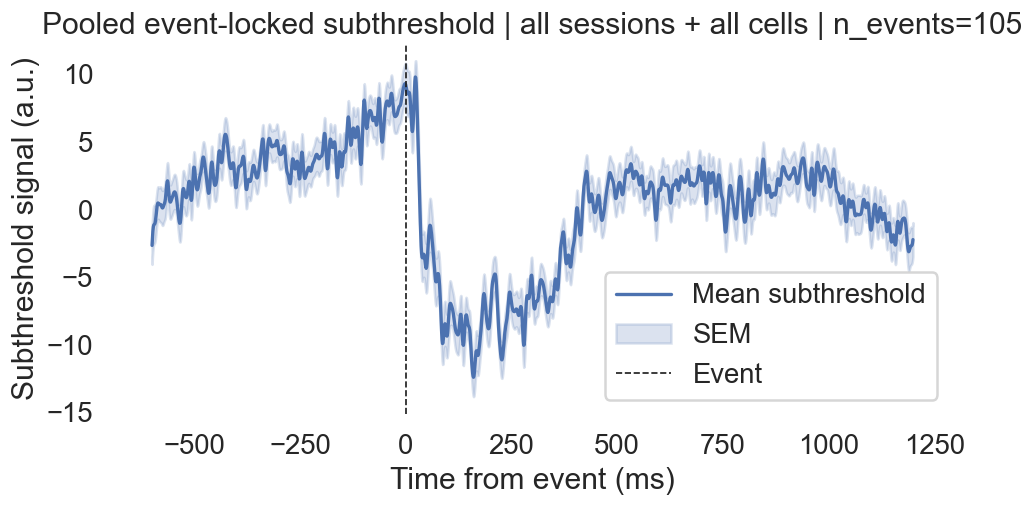

,group,n_events,subth_baseline_mean,subth_response_mean,subth_delta_mean
0,all_sessions_all_cells,105,5.121642,-5.72566,-10.847302


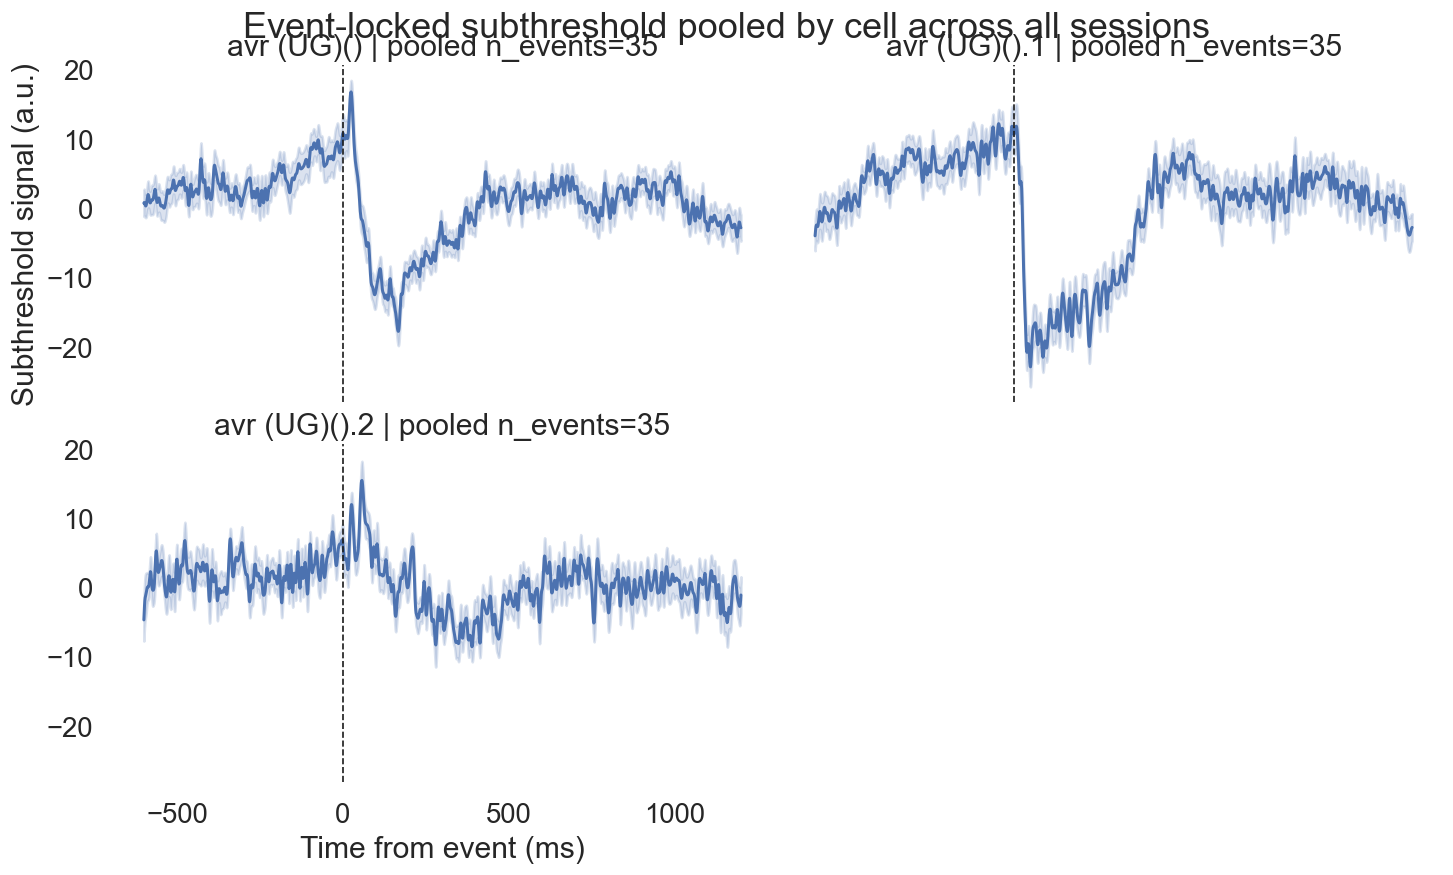

,cell,n_events,subth_baseline_mean,subth_response_mean,subth_delta_mean
0,avr (UG)(),35,5.356069,-5.804860,-11.160930
1,avr (UG)().1,35,7.616779,-13.499426,-21.116205
2,avr (UG)().2,35,2.392078,2.127308,-0.264770


In [10]:
# ==============================
# Subthreshold <-> event relation
# ==============================
def event_locked_subthreshold(trace, time_ms, event_times_ms, window_ms=(-600, 1200)):
    dt = float(np.median(np.diff(time_ms)))
    pre_s = int(round(window_ms[0] / dt))
    post_s = int(round(window_ms[1] / dt))

    snippets = []
    for ev in np.asarray(event_times_ms, dtype=float):
        p = int(np.argmin(np.abs(time_ms - ev)))
        a, b = p + pre_s, p + post_s + 1
        if a < 0 or b > len(trace):
            continue
        snippets.append(trace[a:b])

    if len(snippets) == 0:
        return None, None, 0

    arr = np.vstack(snippets)
    mean = np.mean(arr, axis=0)
    sem = np.std(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros(arr.shape[1])
    rel_t = np.arange(pre_s, post_s + 1) * dt
    return rel_t, (mean, sem, arr), arr.shape[0]

def _window_mean(rel_t, arr2d, w):
    m = (rel_t >= float(w[0])) & (rel_t <= float(w[1]))
    if not np.any(m):
        return np.full(arr2d.shape[0], np.nan)
    return np.nanmean(arr2d[:, m], axis=1)

event_cache = {}
rows = []
all_snippets = []
snippets_by_cell = {i: [] for i in range(n_cells)}
rel_t_ref = None
skipped_for_pooling = 0

for s in processed_sessions:
    ev = _get_session_event_times_ms(s, EVENT_CONFIG, cache=event_cache)
    for c in range(s['n_cells']):
        tr = s['subthreshold'][:, c]
        rel_t, out, n_ev = event_locked_subthreshold(tr, s['time_ms'], ev, window_ms=EVENT_LOCK_WINDOW_MS)
        if out is None:
            continue
        mean_curve, sem_curve, arr = out

        base_vals = _window_mean(rel_t, arr, EVENT_BASELINE_MS)
        resp_vals = _window_mean(rel_t, arr, EVENT_RESPONSE_MS)
        delta = resp_vals - base_vals

        rows.append({
            'session': s['session_name'],
            'cell': s['cell_names'][c],
            'n_events': int(n_ev),
            'subth_baseline_mean': float(np.nanmean(base_vals)),
            'subth_response_mean': float(np.nanmean(resp_vals)),
            'subth_delta_mean': float(np.nanmean(delta)),
        })

        if rel_t_ref is None:
            rel_t_ref = rel_t.copy()
        elif (len(rel_t) != len(rel_t_ref)) or (not np.allclose(rel_t, rel_t_ref, atol=1e-9)):
            skipped_for_pooling += 1
            continue

        all_snippets.append(arr)
        snippets_by_cell[c].append(arr)

event_subth_df = pd.DataFrame(rows)
display(event_subth_df.head(20))

if skipped_for_pooling > 0:
    print(f'Skipped {skipped_for_pooling} traces for pooling due to time-grid mismatch.')

# (a) Pooled across all cells and sessions
if rel_t_ref is not None and len(all_snippets) > 0:
    pooled_arr = np.vstack(all_snippets)
    pooled_mean = np.nanmean(pooled_arr, axis=0)
    pooled_sem = np.nanstd(pooled_arr, axis=0, ddof=1) / np.sqrt(pooled_arr.shape[0]) if pooled_arr.shape[0] > 1 else np.zeros(pooled_arr.shape[1])

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(rel_t_ref, pooled_mean, color=SUBTH_COLORS['pooled'], lw=2, label='Mean subthreshold')
    ax.fill_between(rel_t_ref, pooled_mean - pooled_sem, pooled_mean + pooled_sem, color=SUBTH_COLORS['pooled'], alpha=0.2, label='SEM')
    ax.axvline(0, color='k', ls='--', lw=1, label='Event')
    ax.set_title(f'Pooled event-locked subthreshold | all sessions + all cells | n_events={pooled_arr.shape[0]}')
    ax.set_xlabel('Time from event (ms)')
    ax.set_ylabel('Subthreshold signal (a.u.)')
    ax.legend(loc='best')
    sns.despine(ax=ax, left=True, bottom=True)
    plt.show()

    pooled_base = _window_mean(rel_t_ref, pooled_arr, EVENT_BASELINE_MS)
    pooled_resp = _window_mean(rel_t_ref, pooled_arr, EVENT_RESPONSE_MS)
    pooled_delta = pooled_resp - pooled_base
    pooled_all_summary = pd.DataFrame([{
        'group': 'all_sessions_all_cells',
        'n_events': int(pooled_arr.shape[0]),
        'subth_baseline_mean': float(np.nanmean(pooled_base)),
        'subth_response_mean': float(np.nanmean(pooled_resp)),
        'subth_delta_mean': float(np.nanmean(pooled_delta)),
    }])
    display(pooled_all_summary)
else:
    print('No pooled event snippets available across all sessions/cells.')

# (b) Pooled by cell across all sessions
ncols = 2
nrows = int(np.ceil(n_cells / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows), sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

per_cell_rows = []
for c in range(n_cells):
    ax = axes[c]
    if len(snippets_by_cell[c]) == 0 or rel_t_ref is None:
        ax.set_title(f"{cell_names[c]} (no events)")
        sns.despine(ax=ax, left=True, bottom=True)
        continue

    cell_arr = np.vstack(snippets_by_cell[c])
    cell_mean = np.nanmean(cell_arr, axis=0)
    cell_sem = np.nanstd(cell_arr, axis=0, ddof=1) / np.sqrt(cell_arr.shape[0]) if cell_arr.shape[0] > 1 else np.zeros(cell_arr.shape[1])

    ax.plot(rel_t_ref, cell_mean, color=SUBTH_COLORS['ss'], lw=1.8)
    ax.fill_between(rel_t_ref, cell_mean - cell_sem, cell_mean + cell_sem, color=SUBTH_COLORS['ss'], alpha=0.2)
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_title(f"{cell_names[c]} | pooled n_events={cell_arr.shape[0]}")
    sns.despine(ax=ax, left=True, bottom=True)

    base_vals = _window_mean(rel_t_ref, cell_arr, EVENT_BASELINE_MS)
    resp_vals = _window_mean(rel_t_ref, cell_arr, EVENT_RESPONSE_MS)
    delta = resp_vals - base_vals
    per_cell_rows.append({
        'cell': cell_names[c],
        'n_events': int(cell_arr.shape[0]),
        'subth_baseline_mean': float(np.nanmean(base_vals)),
        'subth_response_mean': float(np.nanmean(resp_vals)),
        'subth_delta_mean': float(np.nanmean(delta)),
    })

for i in range(n_cells, len(axes)):
    axes[i].axis('off')

fig.suptitle('Event-locked subthreshold pooled by cell across all sessions', y=1.02)
axes[0].set_ylabel('Subthreshold signal (a.u.)')
for ax in axes[-ncols:]:
    ax.set_xlabel('Time from event (ms)')
plt.show()

per_cell_event_summary_df = pd.DataFrame(per_cell_rows)
display(per_cell_event_summary_df)

,pair,n_event_windows,pre_r_mean,post_r_mean,delta_r_mean,perm_p_two_sided,fdr_q
0,avr (UG)() <-> avr (UG)().2,35,0.127992,0.198777,0.070785,0.216557,0.628674
1,avr (UG)() <-> avr (UG)().1,35,0.392216,0.381367,-0.010848,0.842232,0.842232
2,avr (UG)().1 <-> avr (UG)().2,35,0.292057,0.253256,-0.038801,0.419116,0.628674


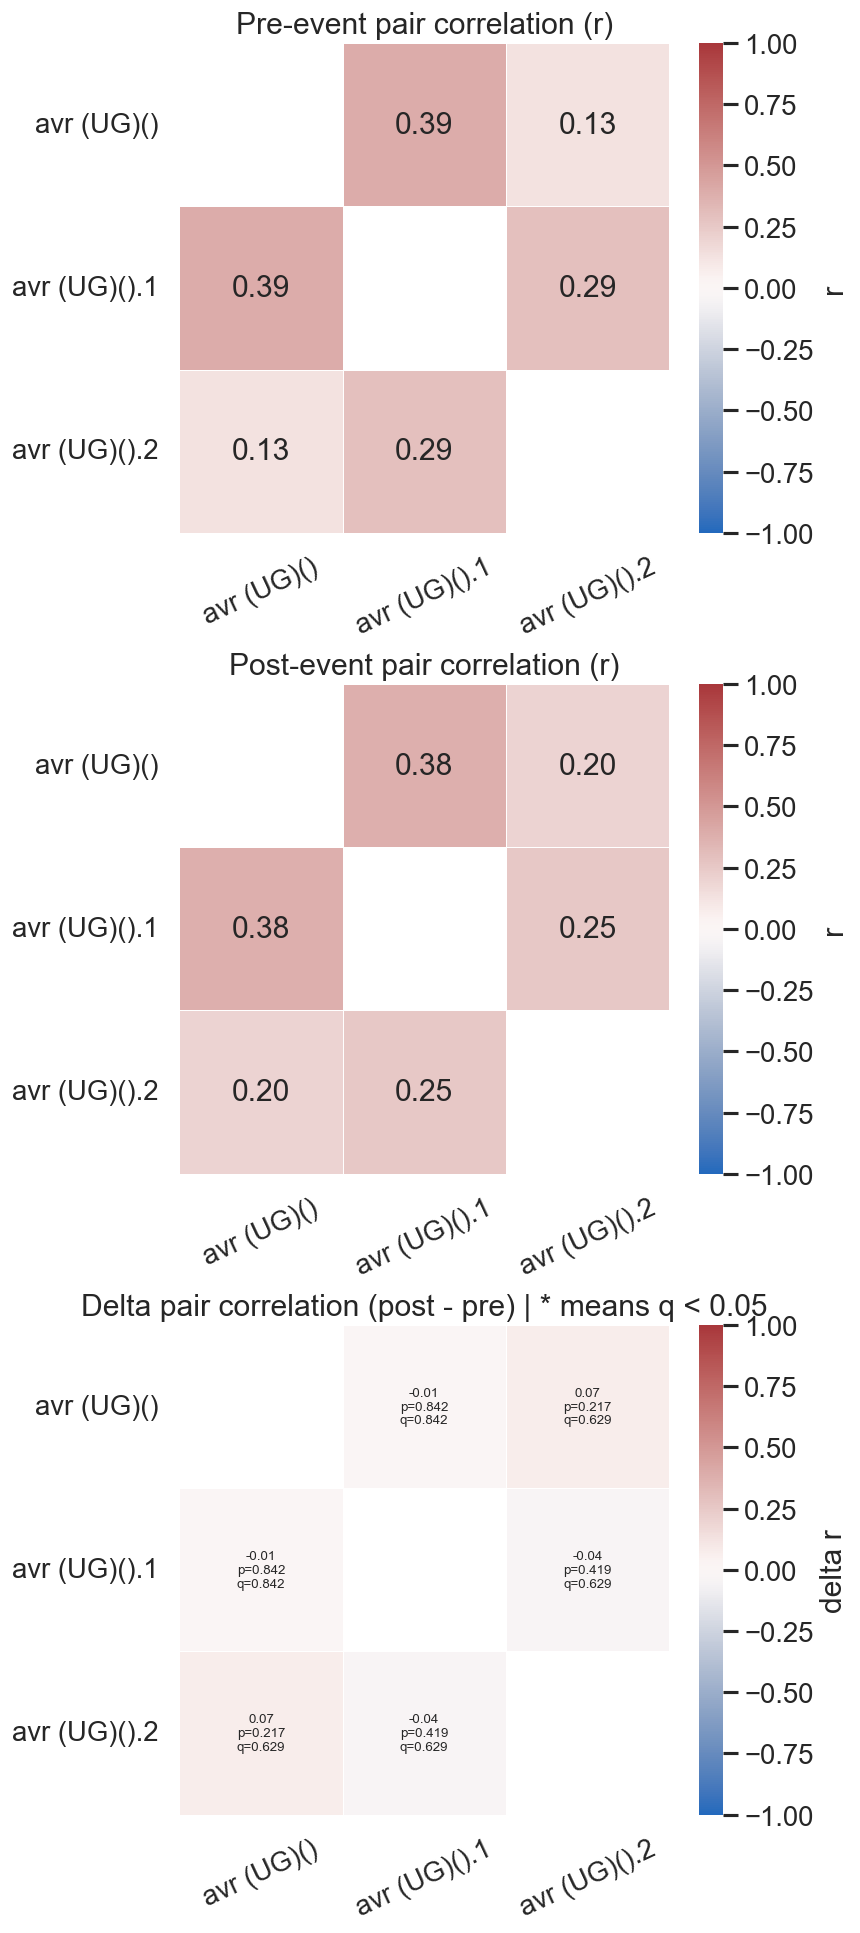

,cell_i,cell_j,pair,n_sessions,mean_r,median_r,std_r,perm_p_two_sided,mean_r_ci_lo,mean_r_ci_hi,positive_fraction,fdr_q
0,avr (UG)(),avr (UG)().1,avr (UG)() <-> avr (UG)().1,7,0.443216,0.443452,0.046449,0.015397,0.409550,0.474536,1.0,0.016197
1,avr (UG)().1,avr (UG)().2,avr (UG)().1 <-> avr (UG)().2,7,0.256347,0.270284,0.110337,0.016197,0.176505,0.330057,1.0,0.016197
2,avr (UG)(),avr (UG)().2,avr (UG)() <-> avr (UG)().2,7,0.183006,0.195958,0.069858,0.015797,0.131496,0.229371,1.0,0.016197


Method detail (non-event-locked robustness):
1) Compute whole-recording zero-lag Pearson r for each pair in each session.
2) For each pair, test whether mean r differs from 0 with a two-sided sign-flip permutation test.
3) Build bootstrap confidence intervals for mean r by resampling session-level r values with replacement.
4) Correct pairwise p-values using Benjamini-Hochberg FDR to obtain q-values.
5) Report robust synchrony as: mean r, CI, permutation p, and FDR q.


,cell_name,n_session_cells,duration_s_mean,mean_of_mean,mean_of_std,mean_of_iqr,mean_of_rms,mean_of_range,mean_of_mad,mean_of_roughness,mean_autocorr_100ms
0,avr (UG)().2,7,39.99996,0.910262,14.333813,17.383046,14.363798,147.748985,8.684856,2.081743,0.042059
1,avr (UG)().1,7,39.99996,0.267964,14.216776,16.425459,14.224651,134.922566,8.158768,1.609311,0.203809
2,avr (UG)(),7,39.99996,0.528490,12.039068,15.292998,12.052481,108.101956,7.605849,1.310587,0.179165


Whole subthreshold dataset summary:
- Sessions analyzed: 7
- Cells per session: 3
- Session-cell traces summarized: 21
- Whole-recording synchrony mean r: 0.294, median r: 0.276
- Whole-recording synchrony positive fraction: 100.0%


In [11]:
# ==============================
# Pairwise synchrony + whole-subthreshold feature report (focused)
# ==============================
PAIR_SYNC_CONFIG = {
    'min_window_samples': 25,
    'n_perm': 5000,
    'n_boot': 3000,
    'alpha': 0.05,
    'rng_seed': 123,
}

def _safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) < 5:
        return np.nan
    x = x[good]
    y = y[good]
    sx = np.std(x)
    sy = np.std(y)
    if sx <= 0 or sy <= 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def _perm_p_two_sided(values, n_perm=5000, rng=None):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    obs = float(np.mean(vals))
    if np.allclose(vals, 0.0):
        return 1.0
    rng = np.random.default_rng() if rng is None else rng
    signs = rng.choice([-1.0, 1.0], size=(int(n_perm), len(vals)))
    null_means = np.mean(signs * vals[None, :], axis=1)
    p = (1.0 + np.sum(np.abs(null_means) >= abs(obs))) / (float(n_perm) + 1.0)
    return float(p)

def _bootstrap_ci_mean(values, n_boot=3000, alpha=0.05, rng=None):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.integers(0, len(vals), size=(int(n_boot), len(vals)))
    boots = np.mean(vals[idx], axis=1)
    lo = float(np.quantile(boots, alpha / 2.0))
    hi = float(np.quantile(boots, 1.0 - alpha / 2.0))
    return lo, hi

def _bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    finite = np.isfinite(p)
    if not np.any(finite):
        return q
    pf = p[finite]
    m = len(pf)
    order = np.argsort(pf)
    ranked = pf[order]
    q_ranked = ranked * m / np.arange(1, m + 1)
    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]
    q_ranked = np.clip(q_ranked, 0.0, 1.0)
    back = np.empty_like(q_ranked)
    back[order] = q_ranked
    q[finite] = back
    return q

def _lag_autocorr(x, lag_samples):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= lag_samples + 5:
        return np.nan
    x0 = x[:-lag_samples]
    x1 = x[lag_samples:]
    return _safe_corr(x0, x1)

def _pair_matrix(cell_names, pair_summary, value_col):
    n = len(cell_names)
    mat = np.full((n, n), np.nan, dtype=float)
    np.fill_diagonal(mat, np.nan)
    for i, ci in enumerate(cell_names):
        for j, cj in enumerate(cell_names):
            if i >= j:
                continue
            m = pair_summary[(pair_summary['cell_i'] == ci) & (pair_summary['cell_j'] == cj)]
            if len(m) == 0:
                m = pair_summary[(pair_summary['cell_i'] == cj) & (pair_summary['cell_j'] == ci)]
            if len(m):
                v = float(m[value_col].iloc[0])
                mat[i, j] = v
                mat[j, i] = v
    return mat

def _pair_stat_matrix(cell_names, pair_summary, value_col):
    n = len(cell_names)
    mat = np.full((n, n), np.nan, dtype=float)
    for _, row in pair_summary.iterrows():
        ci = str(row['cell_i'])
        cj = str(row['cell_j'])
        if ci not in cell_names or cj not in cell_names:
            continue
        i = cell_names.index(ci)
        j = cell_names.index(cj)
        v = float(row[value_col]) if np.isfinite(row[value_col]) else np.nan
        mat[i, j] = v
        mat[j, i] = v
    return mat

rng = np.random.default_rng(PAIR_SYNC_CONFIG['rng_seed'])

# --------------------------------------------------
# A) Event-locked pairwise synchrony (pre/post/delta + p/q)
# --------------------------------------------------
event_pair_rows = []
event_cache_pair = {}

for s in processed_sessions:
    t = np.asarray(s['time_ms'], dtype=float)
    tr = np.asarray(s['subthreshold'], dtype=float)
    ev_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=event_cache_pair)

    for ev in np.asarray(ev_ms, dtype=float):
        pre_mask = (t >= (ev + float(EVENT_BASELINE_MS[0]))) & (t <= (ev + float(EVENT_BASELINE_MS[1])))
        post_mask = (t >= (ev + float(EVENT_RESPONSE_MS[0]))) & (t <= (ev + float(EVENT_RESPONSE_MS[1])))
        if np.sum(pre_mask) < PAIR_SYNC_CONFIG['min_window_samples'] or np.sum(post_mask) < PAIR_SYNC_CONFIG['min_window_samples']:
            continue

        for i in range(s['n_cells']):
            for j in range(i + 1, s['n_cells']):
                r_pre = _safe_corr(tr[pre_mask, i], tr[pre_mask, j])
                r_post = _safe_corr(tr[post_mask, i], tr[post_mask, j])
                if not (np.isfinite(r_pre) and np.isfinite(r_post)):
                    continue
                event_pair_rows.append({
                    'session': s['session_name'],
                    'event_ms': float(ev),
                    'cell_i': s['cell_names'][i],
                    'cell_j': s['cell_names'][j],
                    'pair': f"{s['cell_names'][i]} <-> {s['cell_names'][j]}",
                    'pre_r': float(r_pre),
                    'post_r': float(r_post),
                    'delta_r': float(r_post - r_pre),
                })

event_pair_df = pd.DataFrame(event_pair_rows)
if len(event_pair_df) == 0:
    print('No valid event windows found for pre/post synchrony analysis.')
else:
    event_pair_summary = (
        event_pair_df
        .groupby(['cell_i', 'cell_j', 'pair'], as_index=False)
        .agg(
            n_event_windows=('delta_r', 'count'),
            pre_r_mean=('pre_r', 'mean'),
            post_r_mean=('post_r', 'mean'),
            delta_r_mean=('delta_r', 'mean'),
            delta_r_median=('delta_r', 'median'),
        )
    )

    robust_rows = []
    for _, row in event_pair_summary.iterrows():
        pair_name = row['pair']
        d = event_pair_df.loc[event_pair_df['pair'] == pair_name, 'delta_r'].values
        p_perm = _perm_p_two_sided(d, n_perm=PAIR_SYNC_CONFIG['n_perm'], rng=rng)
        ci_lo, ci_hi = _bootstrap_ci_mean(
            d,
            n_boot=PAIR_SYNC_CONFIG['n_boot'],
            alpha=PAIR_SYNC_CONFIG['alpha'],
            rng=rng,
        )
        robust_rows.append({
            'pair': pair_name,
            'perm_p_two_sided': p_perm,
            'delta_mean_ci_lo': ci_lo,
            'delta_mean_ci_hi': ci_hi,
            'delta_positive_fraction': float(np.mean(np.asarray(d) > 0)),
        })

    robust_df = pd.DataFrame(robust_rows)
    robust_df['fdr_q'] = _bh_fdr(robust_df['perm_p_two_sided'].values)
    event_pair_summary = event_pair_summary.merge(robust_df, on='pair', how='left')
    event_pair_summary = event_pair_summary.sort_values('delta_r_mean', ascending=False).reset_index(drop=True)

    # Concise pair stats table (delta + p + q)
    delta_stats = event_pair_summary[
        ['pair', 'n_event_windows', 'pre_r_mean', 'post_r_mean', 'delta_r_mean', 'perm_p_two_sided', 'fdr_q']
    ].copy()
    display(delta_stats)

    pre_mat = _pair_matrix(cell_names, event_pair_summary, 'pre_r_mean')
    post_mat = _pair_matrix(cell_names, event_pair_summary, 'post_r_mean')
    delta_mat = _pair_matrix(cell_names, event_pair_summary, 'delta_r_mean')
    p_mat = _pair_stat_matrix(cell_names, event_pair_summary, 'perm_p_two_sided')
    q_mat = _pair_stat_matrix(cell_names, event_pair_summary, 'fdr_q')

    star_mat = np.full((len(cell_names), len(cell_names)), '', dtype=object)
    sig_mask = np.isfinite(q_mat) & (q_mat < PAIR_SYNC_CONFIG['alpha'])
    star_mat[sig_mask] = '*'

    ann_delta = np.full((len(cell_names), len(cell_names)), '', dtype=object)
    for i in range(len(cell_names)):
        for j in range(len(cell_names)):
            if not np.isfinite(delta_mat[i, j]):
                continue
            p_txt = f"{p_mat[i, j]:.3f}" if np.isfinite(p_mat[i, j]) else 'nan'
            q_txt = f"{q_mat[i, j]:.3f}" if np.isfinite(q_mat[i, j]) else 'nan'
            ann_delta[i, j] = f"{delta_mat[i, j]:.2f}\np={p_txt}\nq={q_txt}{star_mat[i, j]}"

    # Vertical layout with p/q/significance restored on delta map
    fig, axes = plt.subplots(3, 1, figsize=(7, 16), constrained_layout=True)

    sns.heatmap(
        pre_mat, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, square=True,
        xticklabels=cell_names, yticklabels=cell_names, cbar_kws={'label': 'r'},
        linewidths=0.5, linecolor='white', ax=axes[0]
    )
    axes[0].set_title('Pre-event pair correlation (r)')

    sns.heatmap(
        post_mat, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, square=True,
        xticklabels=cell_names, yticklabels=cell_names, cbar_kws={'label': 'r'},
        linewidths=0.5, linecolor='white', ax=axes[1]
    )
    axes[1].set_title('Post-event pair correlation (r)')

    sns.heatmap(
        delta_mat, annot=ann_delta, fmt='', cmap='vlag', center=0, vmin=-1, vmax=1, square=True,
        xticklabels=cell_names, yticklabels=cell_names, cbar_kws={'label': 'delta r'},
        annot_kws={'fontsize': 8}, linewidths=0.5, linecolor='white', ax=axes[2]
    )
    axes[2].set_title('Delta pair correlation (post - pre) | * means q < 0.05')

    for ax in axes:
        ax.tick_params(axis='x', rotation=25)
        ax.tick_params(axis='y', rotation=0)
        sns.despine(ax=ax, left=True, bottom=True)
    plt.show()

# --------------------------------------------------
# B) Non-event-locked synchrony robustness (whole recording)
# --------------------------------------------------
global_rows = []
for s in processed_sessions:
    tr = np.asarray(s['subthreshold'], dtype=float)
    for i in range(s['n_cells']):
        for j in range(i + 1, s['n_cells']):
            r0 = _safe_corr(tr[:, i], tr[:, j])
            global_rows.append({
                'session': s['session_name'],
                'cell_i': s['cell_names'][i],
                'cell_j': s['cell_names'][j],
                'pair': f"{s['cell_names'][i]} <-> {s['cell_names'][j]}",
                'whole_recording_r': r0,
            })

global_pair_df = pd.DataFrame(global_rows)

global_pair_summary = (
    global_pair_df
    .groupby(['cell_i', 'cell_j', 'pair'], as_index=False)
    .agg(
        n_sessions=('whole_recording_r', 'count'),
        mean_r=('whole_recording_r', 'mean'),
        median_r=('whole_recording_r', 'median'),
        std_r=('whole_recording_r', 'std'),
    )
    .reset_index(drop=True)
)

global_robust_rows = []
for _, row in global_pair_summary.iterrows():
    pair_name = row['pair']
    vals = global_pair_df.loc[global_pair_df['pair'] == pair_name, 'whole_recording_r'].values
    p_perm = _perm_p_two_sided(vals, n_perm=PAIR_SYNC_CONFIG['n_perm'], rng=rng)
    ci_lo, ci_hi = _bootstrap_ci_mean(
        vals,
        n_boot=PAIR_SYNC_CONFIG['n_boot'],
        alpha=PAIR_SYNC_CONFIG['alpha'],
        rng=rng,
    )
    global_robust_rows.append({
        'pair': pair_name,
        'perm_p_two_sided': p_perm,
        'mean_r_ci_lo': ci_lo,
        'mean_r_ci_hi': ci_hi,
        'positive_fraction': float(np.mean(np.asarray(vals) > 0)),
    })

global_robust_df = pd.DataFrame(global_robust_rows)
global_robust_df['fdr_q'] = _bh_fdr(global_robust_df['perm_p_two_sided'].values)
global_pair_summary = global_pair_summary.merge(global_robust_df, on='pair', how='left')
global_pair_summary = global_pair_summary.sort_values('mean_r', ascending=False).reset_index(drop=True)
display(global_pair_summary)

print('Method detail (non-event-locked robustness):')
print('1) Compute whole-recording zero-lag Pearson r for each pair in each session.')
print('2) For each pair, test whether mean r differs from 0 with a two-sided sign-flip permutation test.')
print('3) Build bootstrap confidence intervals for mean r by resampling session-level r values with replacement.')
print('4) Correct pairwise p-values using Benjamini-Hochberg FDR to obtain q-values.')
print('5) Report robust synchrony as: mean r, CI, permutation p, and FDR q.')

# --------------------------------------------------
# C) Whole subthreshold feature report (not only synchrony)
# --------------------------------------------------
feature_rows = []
for s in processed_sessions:
    tr = np.asarray(s['subthreshold'], dtype=float)
    fs = float(s['fs'])
    t = np.asarray(s['time_ms'], dtype=float)
    duration_s = float((t[-1] - t[0]) / 1000.0) if len(t) > 1 else np.nan
    lag_100 = max(1, int(round(0.100 * fs)))

    for c, cname in enumerate(s['cell_names']):
        x = np.asarray(tr[:, c], dtype=float)
        gx = x[np.isfinite(x)]
        if len(gx) < 5:
            continue
        dx = np.diff(gx)
        feature_rows.append({
            'session': s['session_name'],
            'cell_name': cname,
            'duration_s': duration_s,
            'subth_mean': float(np.mean(gx)),
            'subth_std': float(np.std(gx)),
            'subth_iqr': float(np.quantile(gx, 0.75) - np.quantile(gx, 0.25)),
            'subth_rms': float(np.sqrt(np.mean(gx**2))),
            'subth_range': float(np.max(gx) - np.min(gx)),
            'subth_mad': float(np.median(np.abs(gx - np.median(gx)))),
            'roughness_mean_abs_diff': float(np.mean(np.abs(dx))) if len(dx) else np.nan,
            'autocorr_100ms': _lag_autocorr(gx, lag_100),
        })

subth_feature_df = pd.DataFrame(feature_rows)

subth_feature_summary = (
    subth_feature_df
    .groupby('cell_name', as_index=False)
    .agg(
        n_session_cells=('session', 'count'),
        duration_s_mean=('duration_s', 'mean'),
        mean_of_mean=('subth_mean', 'mean'),
        mean_of_std=('subth_std', 'mean'),
        mean_of_iqr=('subth_iqr', 'mean'),
        mean_of_rms=('subth_rms', 'mean'),
        mean_of_range=('subth_range', 'mean'),
        mean_of_mad=('subth_mad', 'mean'),
        mean_of_roughness=('roughness_mean_abs_diff', 'mean'),
        mean_autocorr_100ms=('autocorr_100ms', 'mean'),
    )
    .sort_values('mean_of_std', ascending=False)
    .reset_index(drop=True)
)
display(subth_feature_summary)

print('Whole subthreshold dataset summary:')
print(f"- Sessions analyzed: {len(processed_sessions)}")
print(f"- Cells per session: {n_cells}")
print(f"- Session-cell traces summarized: {len(subth_feature_df)}")
if len(global_pair_df) > 0:
    valid_global = global_pair_df['whole_recording_r'].dropna().values
    print(f"- Whole-recording synchrony mean r: {np.mean(valid_global):.3f}, median r: {np.median(valid_global):.3f}")
    print(f"- Whole-recording synchrony positive fraction: {np.mean(valid_global > 0) * 100:.1f}%")

## Notes

- To use manual event timing only, set `EVENT_DETECTION_CONFIG['auto_detect_event'] = False`.
- To compare filter choices, rerun with `LOWPASS_CUTOFF_HZ` = 50, 80, and 100.
- To increase spike artifact suppression, widen `SPIKE_MASK_SS_MS` / `SPIKE_MASK_CS_MS`.
- If `EXPORT_RESULTS=True`, you can extend export by saving `spike_subth_df` and `event_subth_df` to CSV in `EXPORT_DIR`.